# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

---
## Parte 0. Su variante

Cada quien tiene **datos distintos**: las 12 variables juegan papeles diferentes según
la persona. Copiar las predicciones de alguien más da un MSE malísimo. Comparar
*métodos* entre ustedes, en cambio, es buena idea y se los recomiendo.

Su carpeta de datos se identifica con su **clave única del ITAM**.

In [1]:
import hashlib
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 110
SEMILLA = 42

In [2]:
# TODO: pongan su clave única del ITAM (con o sin ceros a la izquierda, da lo mismo)
CLAVE_UNICA = "214245"

# De la clave sale el nombre de su carpeta. No lo cambien a mano.
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]

# Funciona corriendo el notebook desde `tareas/` o desde la raíz del repo
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "tareas/tarea_01_datos").exists())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA

assert CLAVE_UNICA, "Escriban su clave única en CLAVE_UNICA."
assert MIS_DATOS.exists(), (
    f"No existe la carpeta {CARPETA}. Revisen su clave única: si está mal escrita, "
    f"el nombre de la carpeta sale distinto y no van a encontrar sus datos."
)

train = pd.read_csv(MIS_DATOS / "train.csv")
test = pd.read_csv(MIS_DATOS / "test.csv")

VARIABLES = [f"x{i}" for i in range(1, 13)]
print(f"Su variante: {CARPETA}")
print(f"train: {train.shape}   test: {test.shape}")
train.head()

Su variante: vca1fec98
train: (800, 13)   test: (400, 12)


,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
0,-1.836324,0.466731,-0.385594,0.187457,0.264815,91.179271,-0.423739,0.995881,2.852695,0.155165,3.365516,3.242985,8.809402
1,1.913288,0.144765,-0.281999,0.252806,-0.396607,4.561032,-1.740750,-2.071853,2.379640,-1.011022,1.611325,0.544112,25.081143
2,-0.254875,0.423503,-0.910639,-0.418849,0.195882,21.502290,0.503512,-0.088578,0.302156,1.121312,3.246693,1.311269,10.426509
3,1.017343,0.328149,0.545270,-0.396460,-0.182838,48.473573,0.109023,0.219696,2.073591,-1.809688,0.680854,4.685270,5.140764
4,1.613129,2.916600,0.670921,-0.324329,-0.007261,7.317397,-1.278021,-1.665070,0.090134,-0.475989,1.284861,0.459252,31.384558


In [3]:
# TODO: primer vistazo. ¿Qué rangos tienen las variables? ¿Hay faltantes?
train.describe()

,x1,x2,x3,x4,x5,x6,x7,x8,x9,x10,x11,x12,y
count,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000,800.000000
mean,0.032208,1.731902,-0.002919,0.006969,-0.000688,50.970435,0.015793,0.042094,-0.050520,-0.022713,2.002270,1.592644,12.612012
std,1.165578,2.323425,1.032073,0.288952,0.285109,28.649875,1.153846,0.954227,1.711434,1.705927,1.167180,2.108727,14.727236
min,-1.998676,0.068482,-4.056300,-0.499223,-0.499853,0.010833,-1.997401,-2.685470,-2.996114,-2.999399,0.001914,0.066081,-35.494971
25%,-1.015354,0.495552,-0.684051,-0.240581,-0.254395,26.500688,-0.948506,-0.599923,-1.515034,-1.498492,0.981275,0.538515,2.348407
50%,0.066551,1.008584,0.003655,-0.004167,0.007687,51.995442,-0.025427,0.055133,-0.048910,-0.038969,1.981912,0.990066,12.486319
75%,1.049276,2.111984,0.668989,0.262954,0.232466,75.290937,1.020614,0.676215,1.374177,1.376076,3.016567,1.909180,21.937469
max,1.997882,28.564349,3.180068,0.499448,0.495974,99.932808,1.999167,3.406516,2.991040,2.980858,3.998335,35.817763,65.559067


In [4]:
print(train.isnull().sum())

x1     0
x2     0
x3     0
x4     0
x5     0
x6     0
x7     0
x8     0
x9     0
x10    0
x11    0
x12    0
y      0
dtype: int64


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 13 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   x1      800 non-null    float64
 1   x2      800 non-null    float64
 2   x3      800 non-null    float64
 3   x4      800 non-null    float64
 4   x5      800 non-null    float64
 5   x6      800 non-null    float64
 6   x7      800 non-null    float64
 7   x8      800 non-null    float64
 8   x9      800 non-null    float64
 9   x10     800 non-null    float64
 10  x11     800 non-null    float64
 11  x12     800 non-null    float64
 12  y       800 non-null    float64
dtypes: float64(13)
memory usage: 81.4 KB


### 0.1 El baseline que hay que ganar

Este es el modelo de referencia: una regresión lineal con las 12 variables **tal como
vienen**, sin transformar nada. Su MSE sobre el conjunto de prueba es, por definición, la
calificación **5.0**.

Se lo damos corrido para que arranquen sabiendo exactamente qué hay que superar.

In [6]:
X_train, X_val, y_train, y_val = train_test_split(
    train[VARIABLES], train["y"], test_size=0.25, random_state=SEMILLA
)

baseline = LinearRegression().fit(X_train, y_train)
mse_baseline = mean_squared_error(y_val, baseline.predict(X_val))

print(f"MSE del baseline en validación: {mse_baseline:.2f}")
print(f"R² del baseline en validación : {baseline.score(X_val, y_val):.3f}")
print(f"\nDesviación estándar de y: {train['y'].std():.2f}")

# Coeficientes del modelo
print("Coeficientes:", baseline.coef_)
print("Intercepto:", baseline.intercept_)

MSE del baseline en validación: 101.98
R² del baseline en validación : 0.507

Desviación estándar de y: 14.73
Coeficientes: [ 6.69838158  0.14056171 -0.12496295  0.92647707  0.80649212  0.14280064
  0.6866283  -0.12438934  0.12296028  2.25658105 -0.85003223  0.84925222]
Intercepto: 5.310307406380328


### 0.2 Cómo medir su progreso sin gastar intentos

Solo tienen 3 calificaciones, y necesitan medirse muchas más veces que eso. La solución
es la de siempre: **partir `train` en entrenamiento y validación**, ajustar en una parte
y medir en la otra. Eso ya lo hicimos en la celda anterior.

Dos advertencias importantes:

- Su MSE de validación **no** va a coincidir exactamente con el oficial. El oficial se
  mide sobre `test.csv`, que son otras 400 observaciones. Su número es una *estimación*
  del oficial, con su propia incertidumbre.
- Si eligen entre muchos modelos usando el mismo conjunto de validación, van a
  sobreajustar la validación. Para decisiones finas, usen validación cruzada
  (`cross_val_score`) en lugar de una sola partición.

**Nunca** ajusten nada usando `test.csv`: no tiene `y`, así que ni podrían — y ese es
justo el punto.

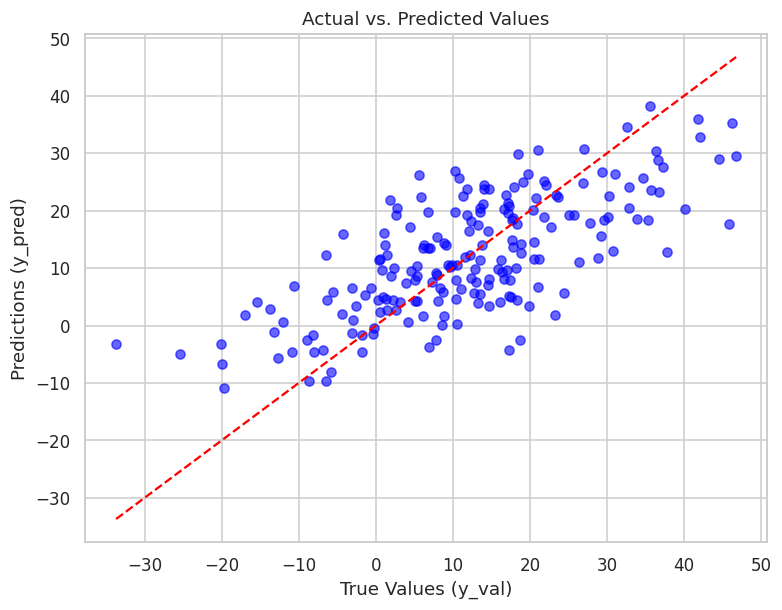

In [7]:
#lo grafico con el matplotlib
y_pred = baseline.predict(X_val)
plt.figure(figsize=(8, 6))
plt.scatter(y_val, y_pred, alpha=0.6, color='blue')

# Draw the perfect prediction diagonal line
max_val = max(y_val.max(), y_pred.max())
min_val = min(y_val.min(), y_pred.min())
plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')

plt.title('Actual vs. Predicted Values')
plt.xlabel('True Values (y_val)')
plt.ylabel('Predictions (y_pred)')
plt.show()

---
## Parte 1. Exploración

Antes de modelar, mírenlos. El objetivo de esta parte **no** es encontrar la respuesta,
es formarse sospechas que después van a confirmar o descartar.

Tres cosas que vale la pena graficar:

1. La distribución de cada variable por separado.
2. `y` contra cada variable, una gráfica por variable.
3. La matriz de correlación.

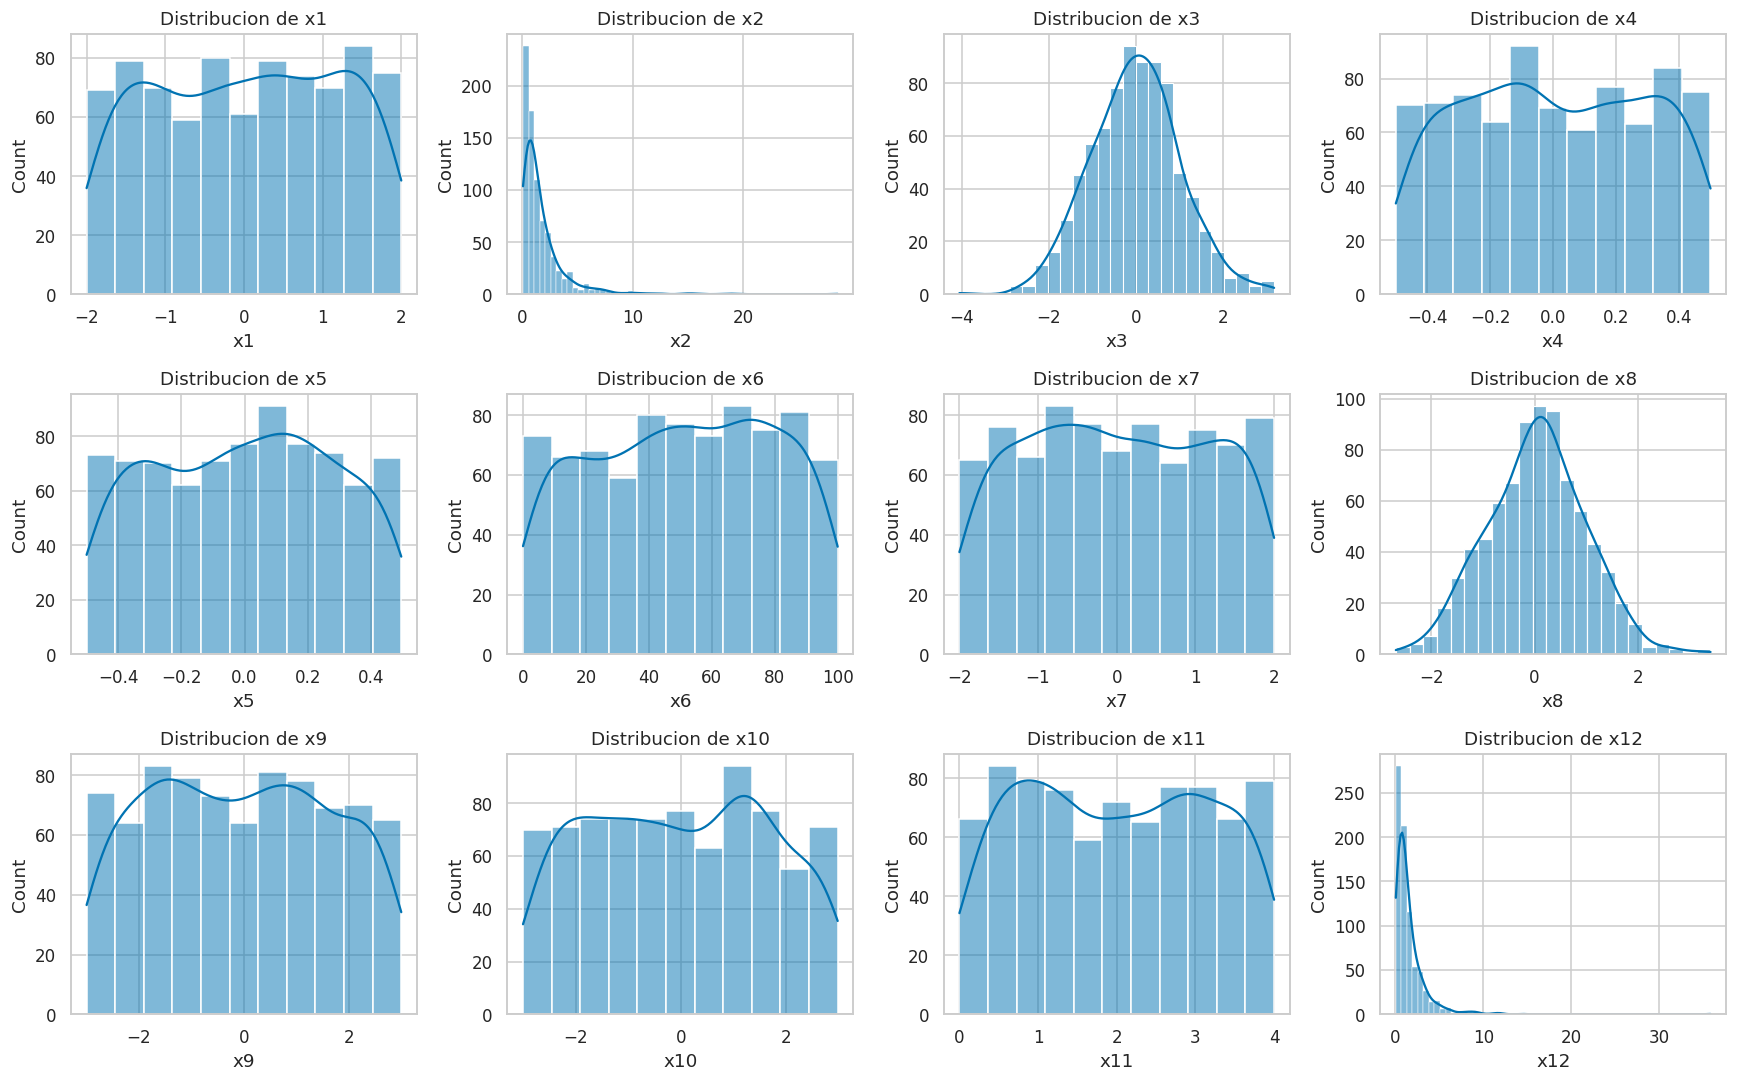

In [8]:
# 1. Distribución de cada variable
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, var in enumerate(VARIABLES):
    sns.histplot(train[var], kde=True, ax=axes[i])
    axes[i].set_title("Distribucion de " + var)
plt.tight_layout()
plt.show()

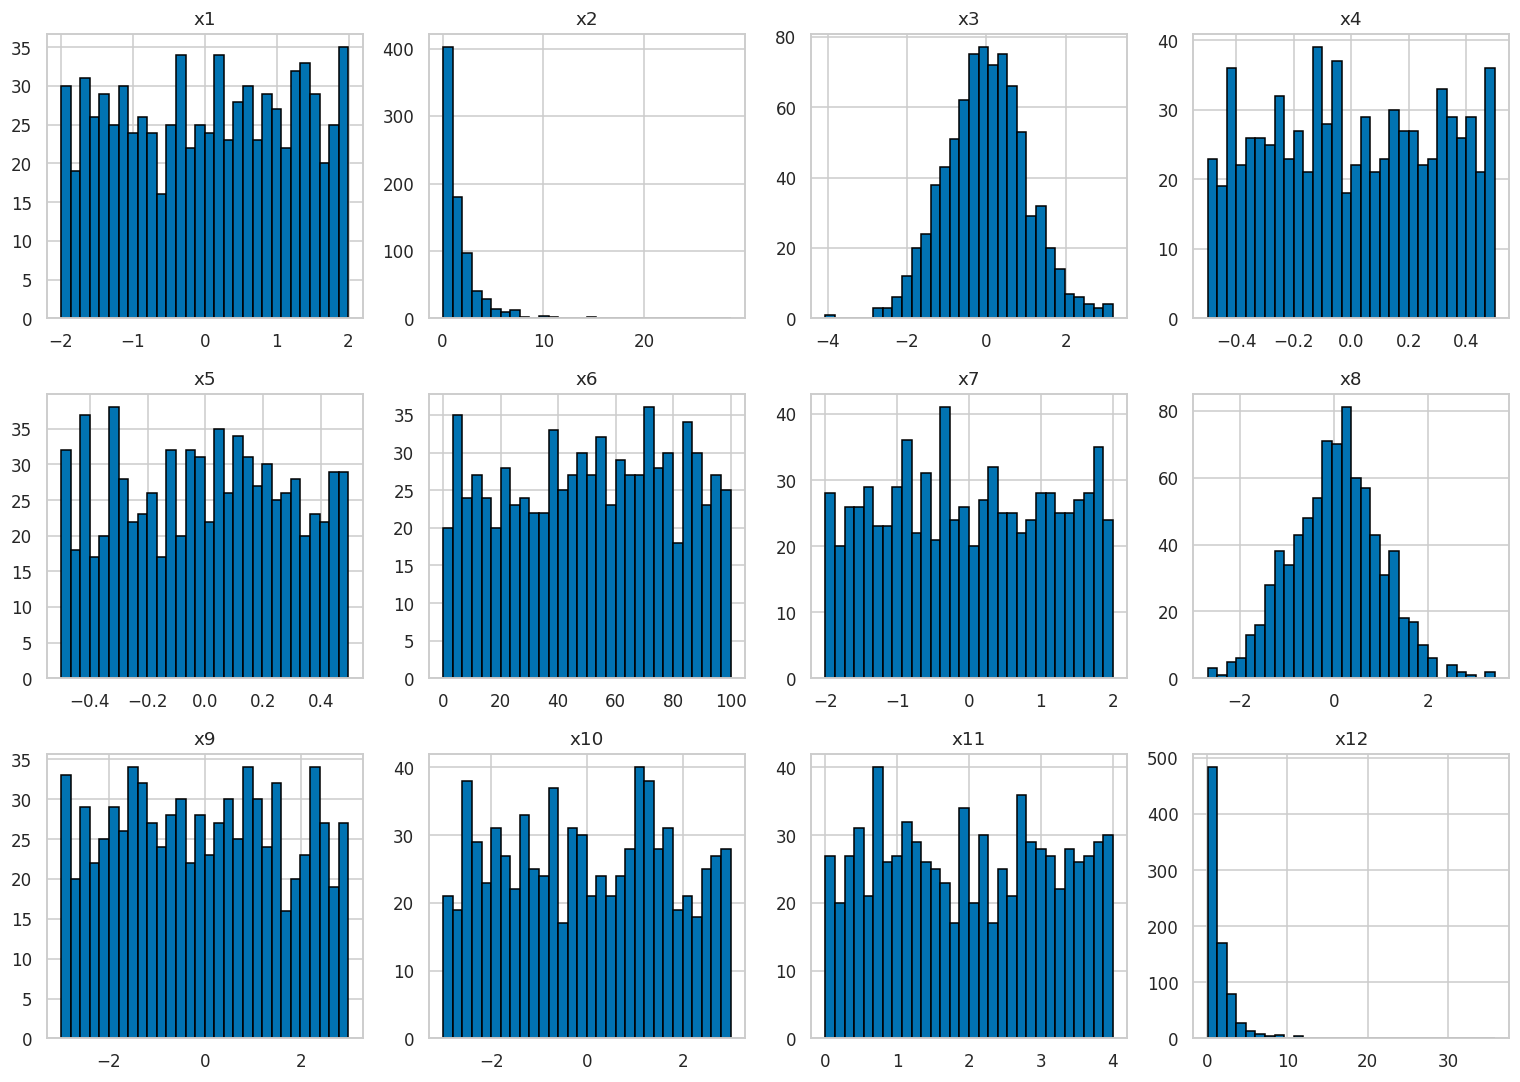

In [9]:
# TODO: distribución de cada una de las 12 variables.
# Pista de método: `train[VARIABLES].hist(...)` hace las 12 de un golpe.
train[VARIABLES].hist(bins=30, figsize=(14, 10), layout=(3, 4), edgecolor="black")
plt.tight_layout()
plt.show()

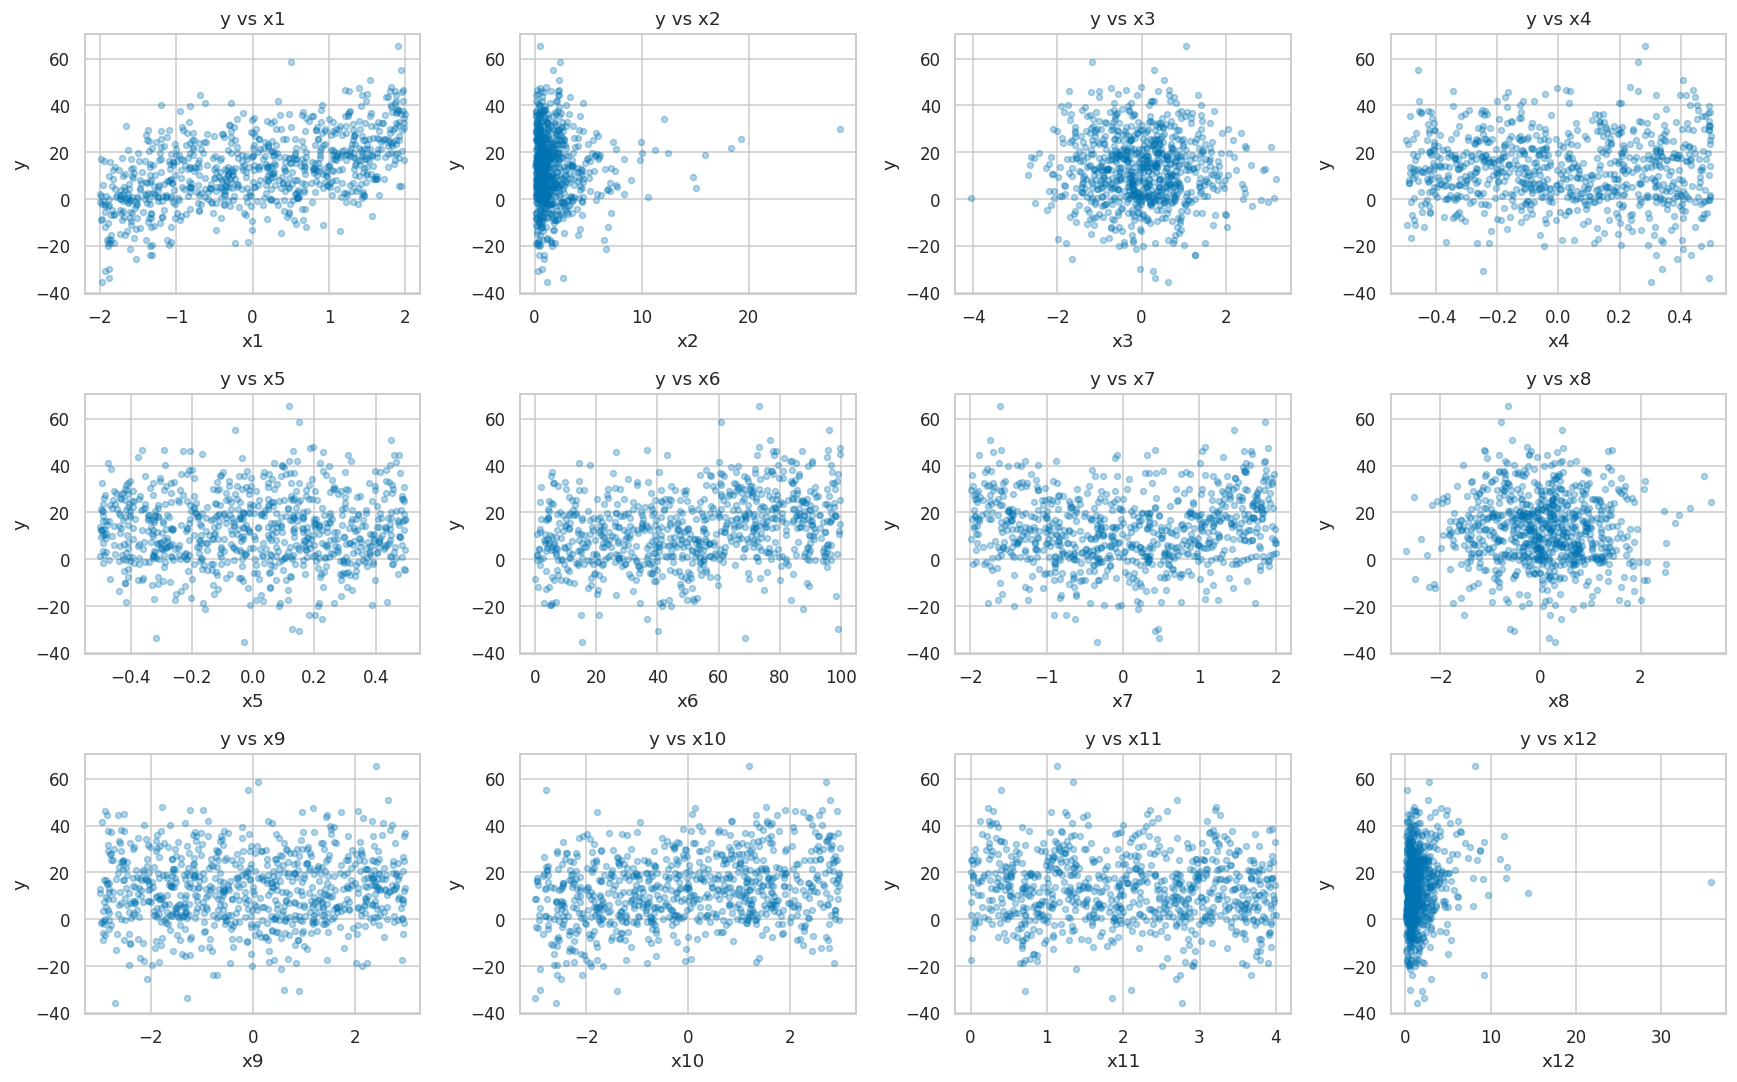

In [10]:
# 2. y vs. cada variable
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()
for i, var in enumerate(VARIABLES):
    axes[i].scatter(train[var], train["y"], alpha=0.3, s=15)
    axes[i].set_title(f"y vs {var}")
    axes[i].set_xlabel(var)
    axes[i].set_ylabel("y")
plt.tight_layout()
plt.show()

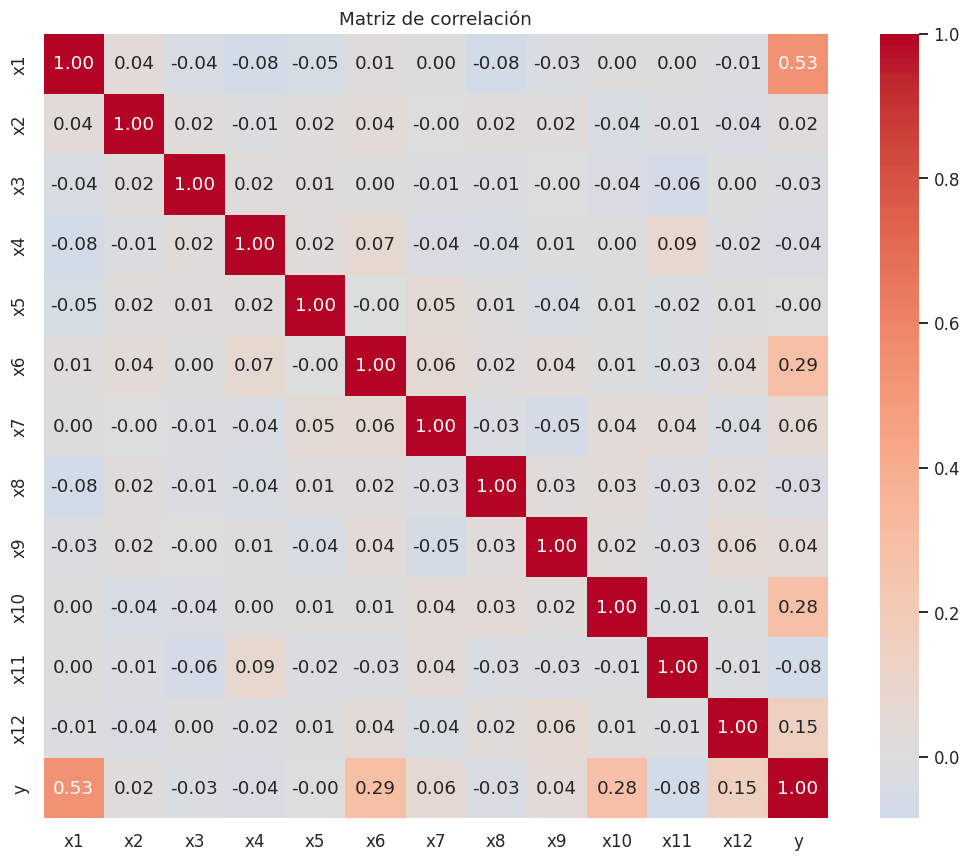

In [11]:
# TODO: matriz de correlación entre las 12 variables y `y`.
corr = train[VARIABLES + ["y"]].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, square=True)
plt.title("Matriz de correlación")
plt.tight_layout()
plt.show()


### 1.1 Registren sus sospechas ahora

Llenen esta tabla **antes** de seguir. Va a ser incómoda de llenar y eso es intencional:
la parte que enseña es volver a leerla al final y ver en qué se equivocaron.

| Variable | ¿Qué sospecho? | ¿En qué gráfica lo vi? | ¿Qué tan seguro estoy? |
|---|---|-----|---|
| `x1` | Relación lineal positiva con `y` | Dispersión x1-y + heatmap (corr = 0.53, la más alta) | Muy seguro |
| `x2` | Muy sesgada a la derecha (casi todo cerca de 0 con cola larga); aparentemente sin relación con `y` en su escala original | Histograma (forma de "L") + dispersión x2-y (nube pegada al 0, sin tendencia) + heatmap (corr = 0.02) | Seguro de que está sesgada; poco seguro de que no aporte nada, un log(x2) podría revelar algo que la correlación lineal no capta |
| `x3` | Distribución aproximadamente normal, sin relación aparente con `y` | Histograma con forma de campana + dispersión sin patrón + heatmap (corr = -0.03) | Seguro |
| `x4` | Uniforme en rango chico (-0.5, 0.5); sin relación con `y` | Histograma plano + dispersión sin tendencia + heatmap (corr = -0.04) | Seguro |
| `x5` | Igual que x4: uniforme, rango chico, sin relación | Histograma plano + dispersión sin tendencia + heatmap (corr ≈ 0.00) | Seguro |
| `x6` | Relación positiva moderada con `y` | Dispersión x6-y (nube que sube conforme crece x6, aunque con mucha dispersion) + heatmap (corr = 0.29) | Bastante seguro, aunque el efecto es más débil que x1 |
| `x7` | Uniforme, sin relacion con `y` | Histograma plano + dispersión sin patrón claro + heatmap (corr = 0.06) | tal vez tenga una relacion debil |
| `x8` | Distribución parecida a normal pero con cola a la derecha, ligeramente sesgada; sin relación lineal con `y` | Histograma asimétrico + dispersión sin tendencia + heatmap (corr = -0.03) | Seguro |
| `x9` | Uniforme, sin relación con `y` | Histograma plano + dispersión sin patrón + heatmap (corr = 0.04) | Seguro |
| `x10` | Relación positiva moderada con `y`, muy parecida a x6 | Dispersión x10-y (tendencia ascendente con ruido) + heatmap (corr = 0.28) | Bastante seguro |
| `x11` | Uniforme (0 a 4), sin relacion con `y` | Histograma plano + dispersión sin patrón visible + heatmap (corr = -0.08) | Poco seguro — es la correlación más "distinta de cero" de las que no muestran nada a simple vista |
| `x12` | Muy sesgada a la derecha (igual que x2, la mayoría cerca de 0, cola larga hasta ~35); relación débil-positiva con `y`, y además correlacionada con `x1` (0.53 en el heatmap, fuera de la fila/columna de `y`) | Histograma en "L" + dispersión x12 vs y (nube pegada a 0) + heatmap (corr con y = 0.15; corr con x1 = 0.53) | Medianamente seguro en el sesgo; la correlación con x1 es sospechosa y vale la pena investigarla

Estoy buscando algo en python que de lo mismo que lo que da el metodo sumary(lm(...)) en R
```
modelo <- lm(y ~ x1 + x2 + ... + x12, data=train)
summary(modelo)
```
Esto te da:
- Coeficientes estimados (𝛽_𝑖)
- Errores estándar de cada coeficiente
- t-values (estadístico de prueba)
- p-values (significancia de cada variable)
- Intervalos de confianza
En Python, sklearn no da p-values. Para eso se usa statsmodels:
Esto te devuelve una tabla muy parecida a la de R:
- coef: el efecto de cada variable en 𝑦
- std err: error estándar del coeficiente
- t: estadístico t
- P>|t|: p-value (si es <0.05, la variable es significativa)
- [0.025, 0.975]: intervalo de confianza del coeficiente

In [12]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)  # añade intercepto; una columna de unos a tu matriz de predictores 𝑋.Esa columna representa el término independiente (𝛽0) de la regresión. Sin esto, el modelo sería forzado a pasar por el origen.
modelo = sm.OLS(y_train, X_train_const).fit() #creas y ajustas un modelo de regresión lineal ordinaria (OLS, Ordinary Least Squares): Estima los coeficientes 𝛽 minimizando la suma de los cuadrados de los residuos. .fit() hace el cálculo y guarda los resultados en el objeto modelo.
print(modelo.summary())


                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.446
Model:                            OLS   Adj. R-squared:                  0.435
Method:                 Least Squares   F-statistic:                     39.42
Date:                Sun, 13 Sep 2026   Prob (F-statistic):           1.58e-67
Time:                        14:42:27   Log-Likelihood:                -2291.6
No. Observations:                 600   AIC:                             4609.
Df Residuals:                     587   BIC:                             4666.
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          5.3103      1.319      4.026      0.0

- Cada coeficiente 𝛽_𝑖 se estima con un cierto error.
- El p‑value es la probabilidad de observar un efecto tan grande (o mayor) que el estimado, si en realidad el efecto fuera cero.
- En otras palabras: mide la evidencia contra la hipótesis nula 𝐻0:𝛽𝑖=0.

p‑value pequeño (< 0.05): ➝ Alta evidencia contra 𝐻0.
➝ Concluimos que la variable sí tiene un efecto significativo en 𝑦.

p‑value grande (> 0.05):➝ No hay suficiente evidencia para decir que el coeficiente es distinto de cero.
➝ Esa variable podría no estar aportando nada útil al modelo.

No es la probabilidad de que la hipótesis sea cierta o falsa.  
Es la probabilidad de ver un resultado igual o más extremo si la hipótesis nula fuera cierta.

- Variables claramente significativas: x1, x6, x10, x11, x12.
- Variables no significativas: x2, x3, x4, x5, x8, x9.
- Variable borderline: x7 (p ≈ 0.089).

El modelo global es significativo, pero no todas las variables aportan.
Podrías considerar simplificar el modelo eliminando las variables con p‑values altos, o aplicar regularización (Lasso/Ridge) para seleccionar automáticamente las más relevantes.

---
## Parte 2. La escalera de residuales

Este es el método central de la tarea, y el que quiero que se lleven de por vida.

Un **residual** es lo que su modelo no logró explicar: `residual = y - ŷ`. Si su modelo
capturó todo lo que había, los residuales deben ser **ruido**: sin forma, sin patrón, sin
estructura. Si al graficar los residuales contra una variable se ve una *forma*, esa
forma es un pedazo de la función que les falta — y la forma les dice qué término agregar.

El ciclo es siempre el mismo:

1. Ajustan el modelo que tienen.
2. Grafican los residuales contra **cada** variable.
3. Si alguna gráfica tiene forma, agregan un término que capture esa forma.
4. Vuelven al paso 1.

Paran cuando ya ninguna gráfica tiene forma, o cuando el MSE deja de bajar.

### ¿Y qué término agrego?

Eso es exactamente lo que tienen que descubrir, y es el trabajo de la tarea.

Lo que sí les conviene es pedirle a su IA el **catálogo**: "¿qué transformaciones existen
para linealizar una relación no lineal?", "¿cómo se modela un efecto que cambia de golpe
a partir de cierto valor?". Eso es conocimiento general y la IA lo tiene completo.

Cuál de esas transformaciones aplica, a cuál de sus doce variables y con qué parámetro,
no se lo puede decir nadie: solo su gráfica. Ahí es donde se aprende.

In [13]:
def ajusta(columnas_extra=None):
    """Ajusta una lineal con las 12 crudas más las columnas derivadas que le pasen.

    `columnas_extra` es un dict {nombre: función que recibe un DataFrame y devuelve
    una Serie}. Así el mismo término se construye igual en train, validación y test,
    que es donde se equivoca todo el mundo.

    Devuelve (modelo, mse_validacion, residuales_de_validacion, constructor).
    """
    columnas_extra = columnas_extra or {}

    def construye(df):
        salida = df[VARIABLES].copy()
        for nombre, f in columnas_extra.items():
            salida[nombre] = f(df)
        return salida

    modelo = LinearRegression().fit(construye(X_train), y_train)
    pred_val = modelo.predict(construye(X_val))
    mse = mean_squared_error(y_val, pred_val)
    return modelo, mse, y_val - pred_val, construye


modelo, mse, residuales, _ = ajusta()
print(f"Modelo con las 12 crudas -> MSE de validación {mse:.2f}")

Modelo con las 12 crudas -> MSE de validación 101.98


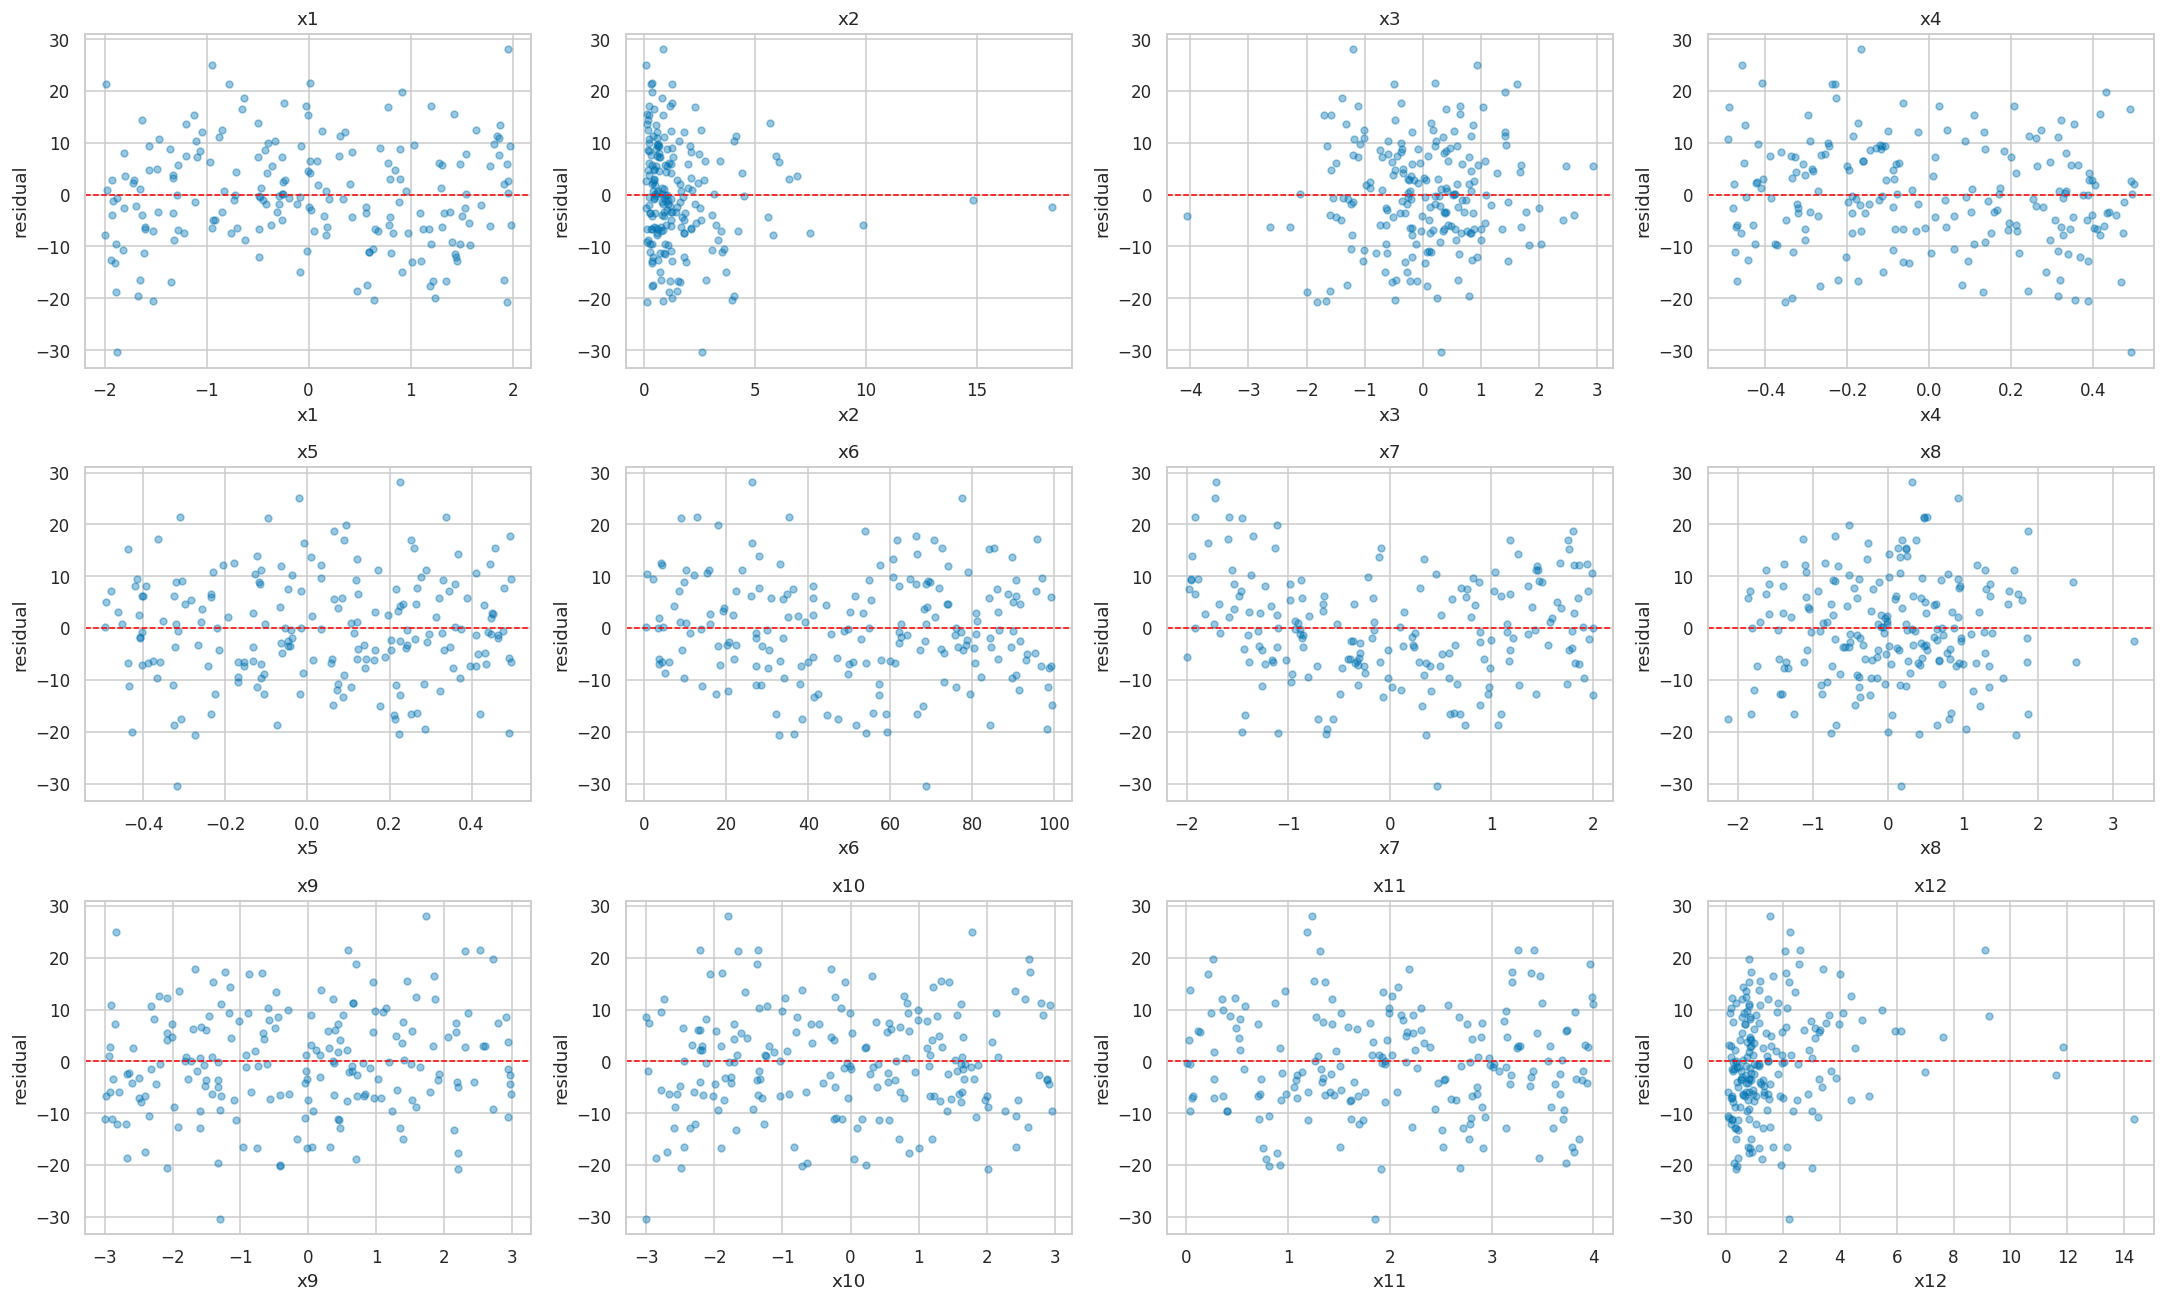

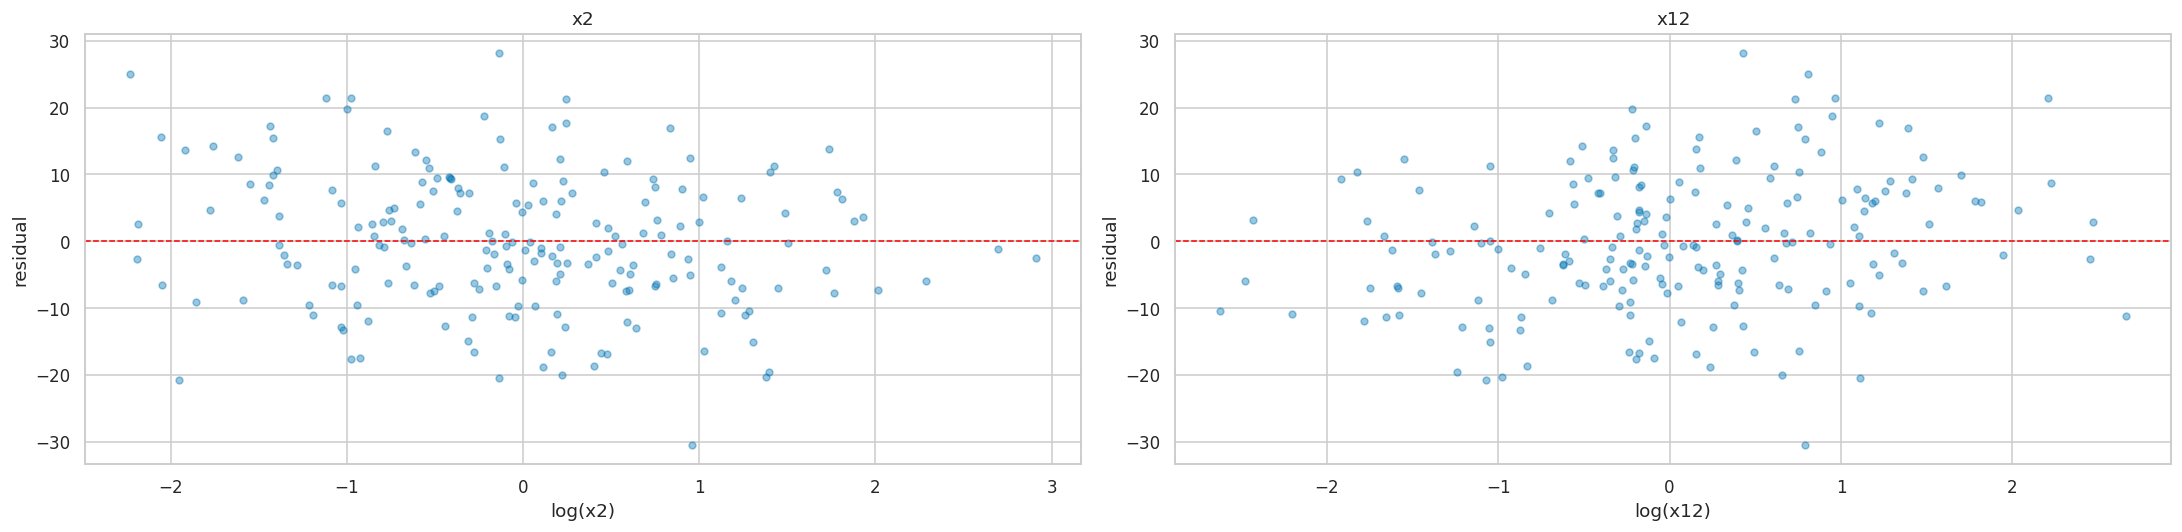

In [14]:
# TODO: grafiquen los residuales contra cada una de las 12 variables.
# Una rejilla de 12 paneles, y en cada uno una línea horizontal en 0 como referencia.
#
# Lo que buscan es FORMA, no dispersión. Una nube gruesa sin patrón está bien;
# una nube que sube, baja, ondula o salta es un término que les falta.
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for var, ax in zip(VARIABLES, axes.flat):
    ax.scatter(X_val[var], residuales, alpha=0.4, s=20)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(var)
    ax.set_ylabel('residual')
    ax.set_title(var)
    
plt.tight_layout()
plt.show()    

# En escala logaritmoca
fig, axes = plt.subplots(1, 2, figsize=(20, 5))
for ax, var in zip(axes, ['x2', 'x12']):
    ax.scatter(np.log(X_val[var]), residuales, alpha=0.4, s=20)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(f'log({var})'); ax.set_ylabel('residual'); ax.set_title(var)

plt.tight_layout(); plt.show()


In [15]:
# TODO: agreguen su primer término y vuelvan a medir.
#
# Así se le pasa una columna derivada a `ajusta`. El término del ejemplo es deliberadamente
# absurdo y NO sirve para nada: solo ilustra la sintaxis del diccionario y del lambda.
#
# modelo, mse, residuales, _ = ajusta({"disparate": lambda d: d["x1"] + d["x2"]})
# print(f"MSE: {mse:.2f}")
#
# Si el MSE bajó mucho, iban bien. Si no se movió, ese término no era. Anoten las dos
# cosas en la bitácora: los intentos fallidos también cuentan.

modelo_x1_sq, mse_x1, res_x1, _ = ajusta({"x1_sq": lambda d: d["x1"]**2})
print(f"x1²        -> MSE: {mse_x1:.2f}  (baseline: {mse:.2f})")

modelo_x3_sq, mse_x3_sq, res_x3_sq, _ = ajusta({"x3_sq": lambda d: d["x3"]**2})
print(f"x3²        -> MSE: {mse_x3_sq:.2f}  (baseline: {mse:.2f})")

modelo_x5_sq, mse_x5_sq, res_x5_sq, _ = ajusta({"x5_sq": lambda d: d["x5"]**2})
print(f"x5²        -> MSE: {mse_x5_sq:.2f}  (baseline: {mse:.2f})")

#Candidato con más forma visible: parábola en x7 con residuales.
modelo_x7_sq, mse_x7_sq, res_x7_sq, _ = ajusta({"x7_sq": lambda d: d["x7"]**2})
print(f"x7²        -> MSE: {mse_x7_sq:.2f}  (baseline: {mse:.2f})")

modelo_x7_3, mse_x7_3, res_x7_3, _ = ajusta({"x7_cu": lambda d: d["x7"]**3})
print(f"x7³        -> MSE: {mse_x7_3:.2f}  (baseline: {mse:.2f})")

# 2. Candidatos por distribución sesgada: log en x2 y x12
# Ambas son estrictamente positivas (mínimo > 0 en el describe()), así que log directo es seguro
modelo_x2, mse_x2, res_x2, _ = ajusta({"log_x2": lambda d: np.log(d["x2"])})
print(f"log(x2)    -> MSE: {mse_x2:.2f}  (baseline: {mse:.2f})")

modelo_x2_sqrt, mse_x2_sqrt, res_x2_sqrt, _ = ajusta({"x2_sqrt": lambda d: np.sqrt(d["x2"])})
print(f"x2^(1/2)   -> MSE: {mse_x2_sqrt:.2f}  (baseline: {mse:.2f})")

modelo_x2_1, mse_x2_1, res_x2_1, _ = ajusta({"x2_1": lambda d: 1 + np.log(1 + d["x2"])})
print(f"1 + log(x2)-> MSE: {mse_x2_1:.2f}  (baseline: {mse:.2f})")

modelo_x12, mse_x12, res_x12, _ = ajusta({"log_x12": lambda d: np.log(d["x12"])})
print(f"log(x12)   -> MSE: {mse_x12:.2f}  (baseline: {mse:.2f})")

modelo_x12_1, mse_x12_1, res_x12_1, _ = ajusta({"x12_1": lambda d: 1 + np.log(1 + d["x12"])})
print(f"1 + log(x12)->MSE: {mse_x12_1:.2f}  (baseline: {mse:.2f})")

modelo_x12_sq, mse_x12_sq, res_x12_sq, _ = ajusta({"x12_sq": lambda d: d["x12"]**2})
print(f"x12²       -> MSE: {mse_x12_sq:.2f}  (baseline: {mse:.2f})")

modelo_x12_sqrt, mse_x12_sqrt, res_x12_sqrt, _ = ajusta({"x12_sqrt": lambda d: np.sqrt(d["x12"])})
print(f"x12^(1/2)  -> MSE: {mse_x12_sqrt:.2f}  (baseline: {mse:.2f})")

x1²        -> MSE: 102.60  (baseline: 101.98)
x3²        -> MSE: 102.07  (baseline: 101.98)
x5²        -> MSE: 102.50  (baseline: 101.98)
x7²        -> MSE: 92.47  (baseline: 101.98)
x7³        -> MSE: 101.74  (baseline: 101.98)
log(x2)    -> MSE: 103.24  (baseline: 101.98)
x2^(1/2)   -> MSE: 102.83  (baseline: 101.98)
1 + log(x2)-> MSE: 102.80  (baseline: 101.98)
log(x12)   -> MSE: 98.91  (baseline: 101.98)
1 + log(x12)->MSE: 98.46  (baseline: 101.98)
x12²       -> MSE: 99.15  (baseline: 101.98)
x12^(1/2)  -> MSE: 98.44  (baseline: 101.98)


In [16]:
modelo_v2, mse_v2, residuales_v2, _ = ajusta({
    "x7_sq": lambda d: d["x7"]**2,
    "log_x12": lambda d: np.log(d["x12"]),
})
print(f"x7² + log(x12) -> MSE: {mse_v2:.2f}  (baseline: {mse:.2f})")

modelo_v2_2, mse_v2_2, residuales_v2_2, _ = ajusta({
    "x7_sq": lambda d: d["x7"]**2,
    "x12_sqrt": lambda d: np.sqrt(d["x12"])
})
print(f"x7² + x12^(1/2) -> MSE: {mse_v2_2:.2f}  (baseline: {mse:.2f})")

modelo_v2_3, mse_v2_3, residuales_v2_3, _ = ajusta({
    "x7_sq": lambda d: d["x7"]**2,
    "x12_1": lambda d: 1 + np.log(1 + d["x12"])
})
print(f"x7² + 1+log(x12) -> MSE: {mse_v2_3:.2f}  (baseline: {mse:.2f})")

x7² + log(x12) -> MSE: 89.70  (baseline: 101.98)
x7² + x12^(1/2) -> MSE: 89.46  (baseline: 101.98)
x7² + 1+log(x12) -> MSE: 89.44  (baseline: 101.98)


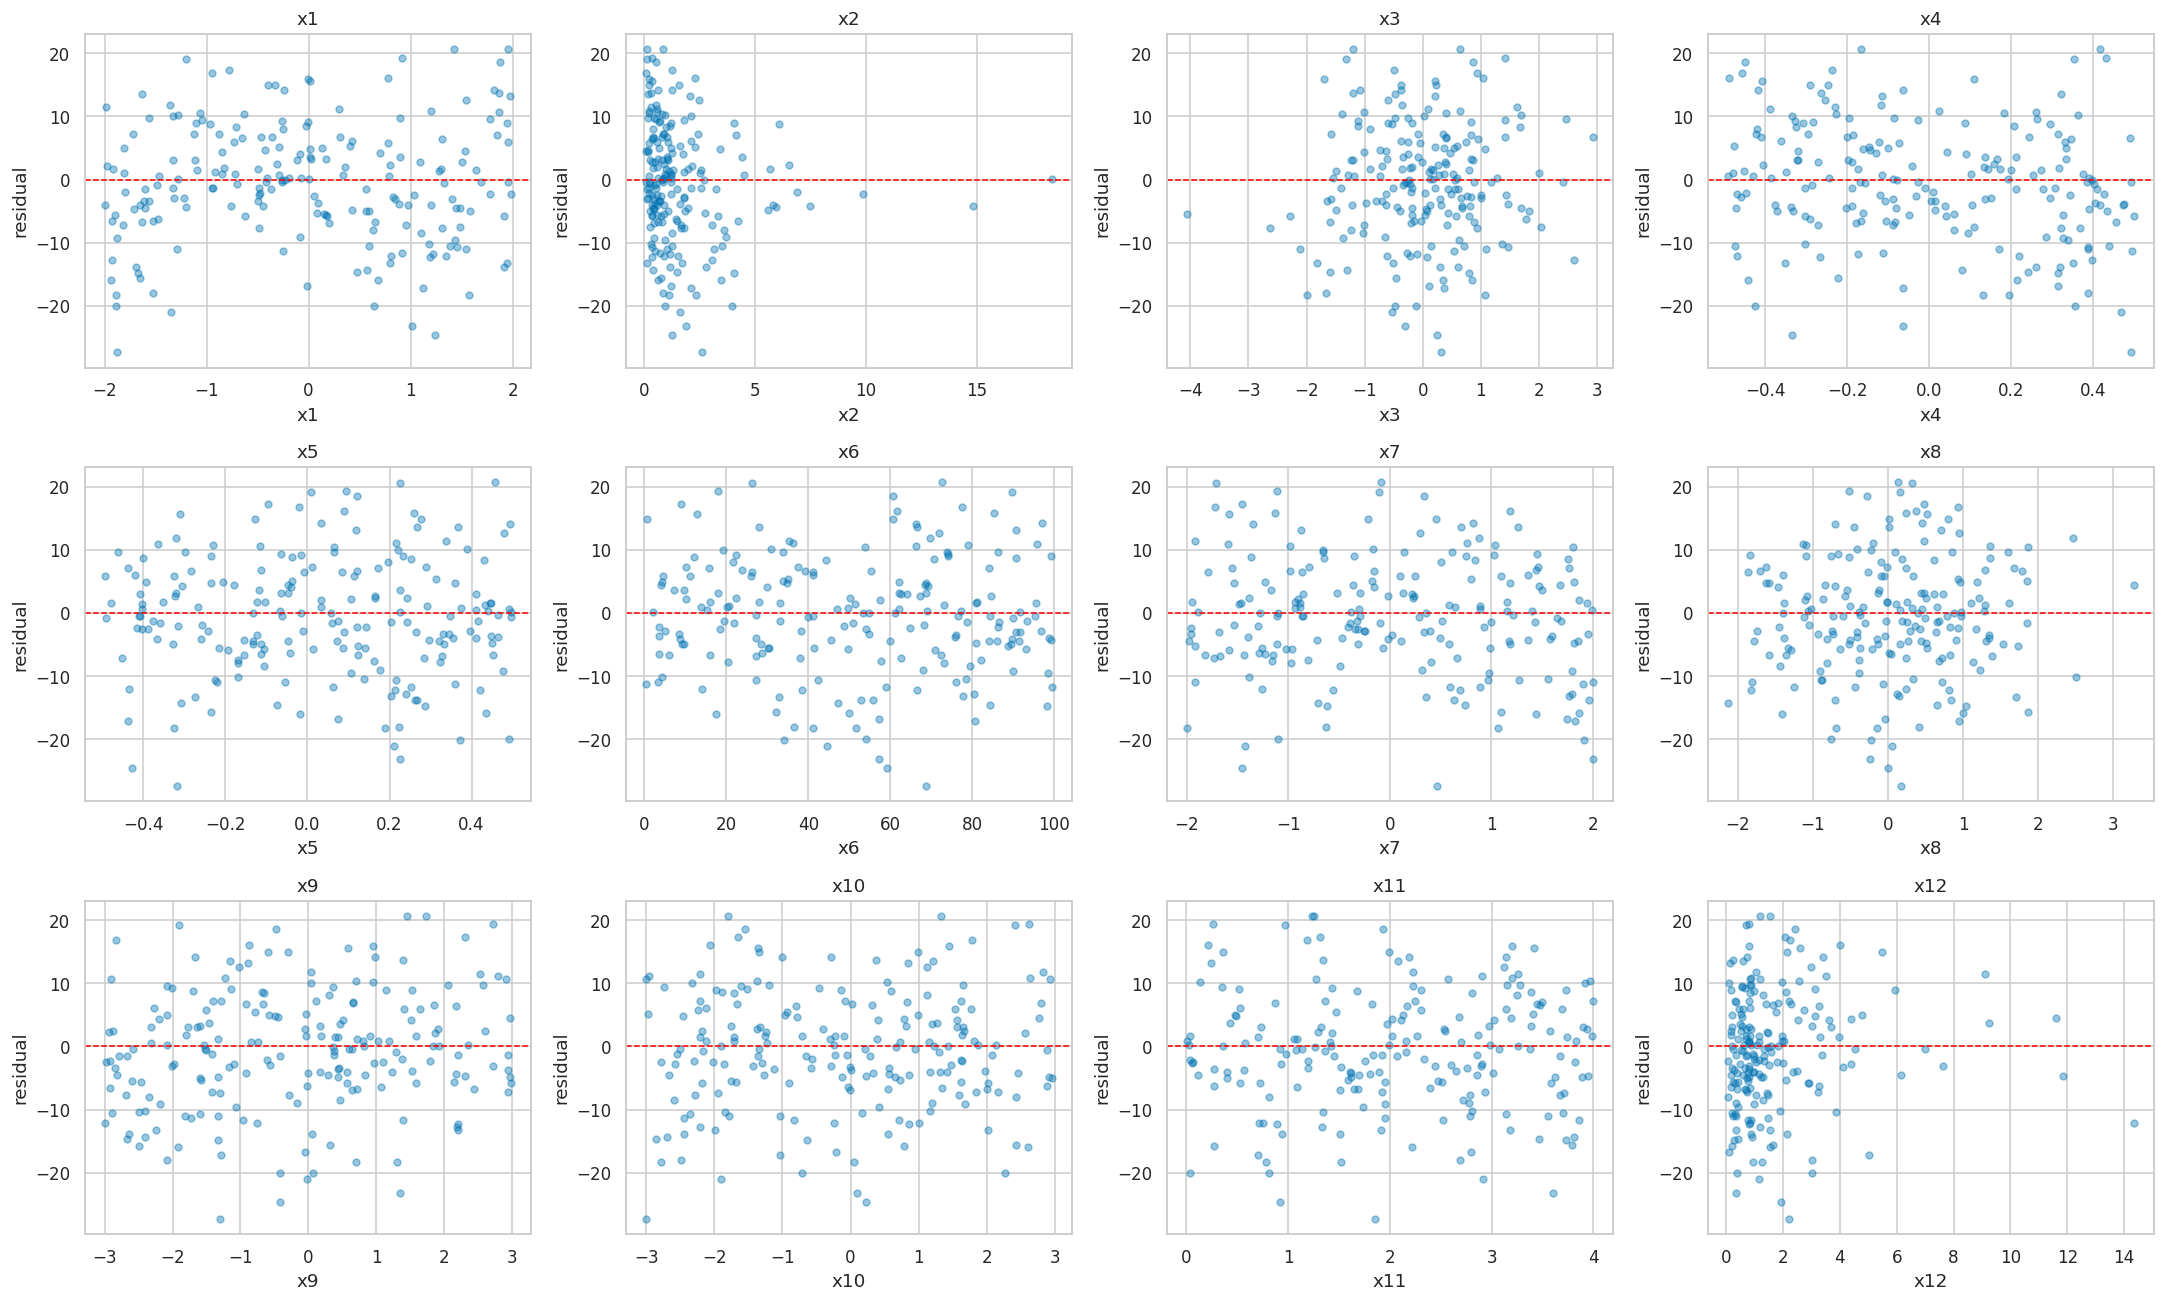

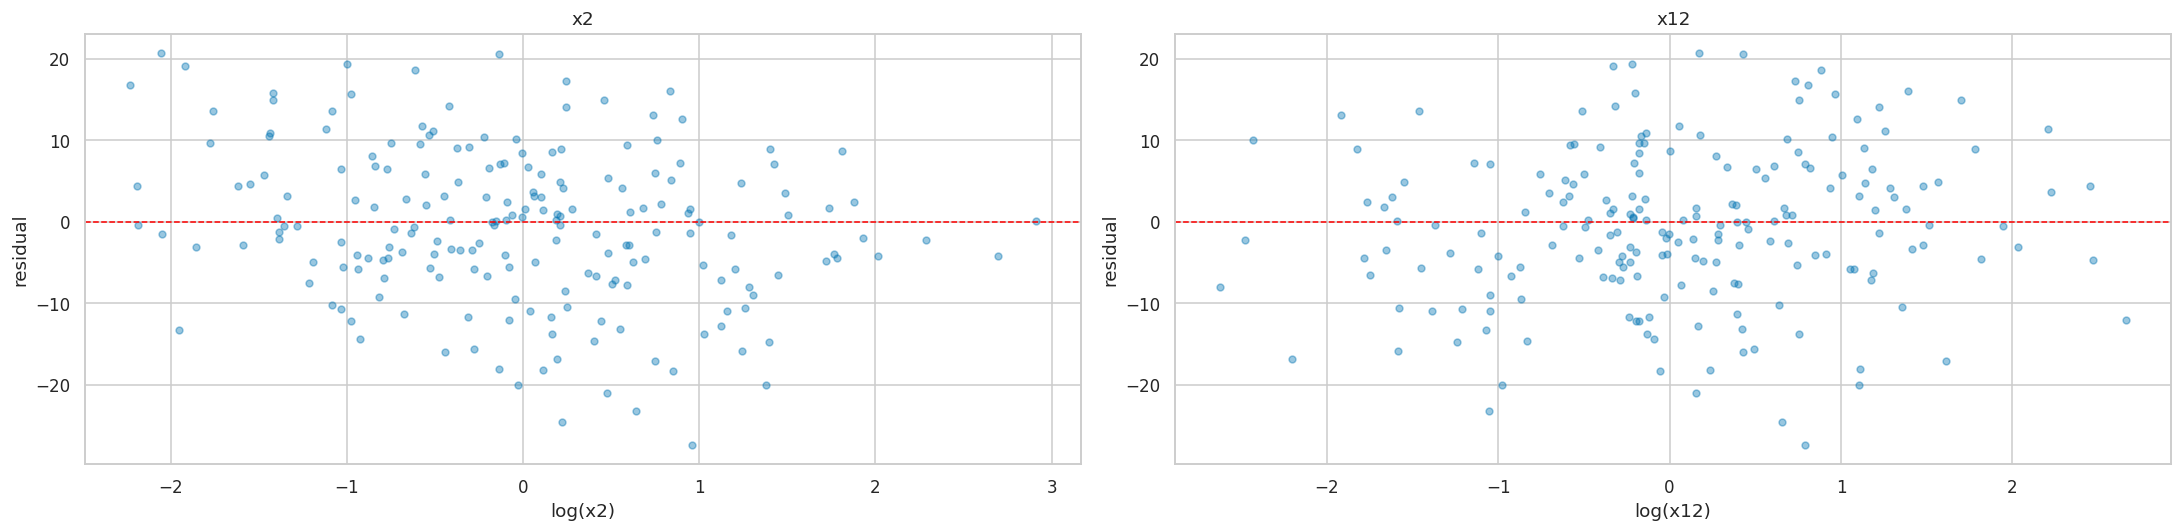

In [17]:
fig, axes = plt.subplots(3, 4, figsize=(20, 12))

for var, ax in zip(VARIABLES, axes.flat):
    ax.scatter(X_val[var], residuales_v2_2, alpha=0.4, s=20)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(var)
    ax.set_ylabel('residual')
    ax.set_title(var)

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(20, 5))
for ax, var in zip(axes, ['x2', 'x12']):
    ax.scatter(np.log(X_val[var]), residuales_v2_2, alpha=0.4, s=20)
    ax.axhline(0, color='red', linestyle='--', linewidth=1)
    ax.set_xlabel(f'log({var})'); ax.set_ylabel('residual'); ax.set_title(var)

plt.tight_layout(); plt.show()

---
## Parte 3. Lo que las gráficas de una variable no pueden ver

Cuando terminen la Parte 2 van a tener un modelo decente y, probablemente, ninguna
gráfica de residuales con forma evidente. Eso **no** significa que ya acabaron.

Hay efectos que son invisibles para cualquier gráfica de una sola variable: pueden tener
correlación cero con `y`, scatter plano y residual sin estructura, y aun así ser de los
efectos más grandes del modelo. Ninguna herramienta de la Parte 2 los encuentra.

Su trabajo aquí es averiguar **qué clase de efectos son, cómo se detectan, y si sus datos
tienen alguno**. Su IA les puede explicar la teoría si le hacen la pregunta correcta; sus
datos son los únicos que pueden contestar si aplica.

Una pista de método y ninguna de contenido: si mirar una variable a la vez no basta,
prueben mirando dos a la vez.

In [18]:
# TODO: exploren aquí.
#
# Son 66 pares de variables y no tienen que revisarlos a ciegas: usen lo que ya
# aprendieron en la Parte 2 para decidir por dónde empezar.
# %%
# 1. Barrido de todos los pares: correlación del residual con el producto
import itertools

candidatos = []
for xi, xj in itertools.combinations(VARIABLES, 2):
    producto = X_val[xi] * X_val[xj]
    corr = np.corrcoef(residuales_v2, producto)[0, 1]
    candidatos.append((abs(corr), xi, xj, corr))

candidatos.sort(reverse=True)
for _, xi, xj, corr in candidatos[:10]:
    print(f"{xi} x {xj}: corr con residual = {corr:.3f}")

x4 x x10: corr con residual = 0.453
x4 x x11: corr con residual = -0.239
x4 x x6: corr con residual = -0.227
x4 x x12: corr con residual = -0.216
x2 x x4: corr con residual = -0.185
x9 x x11: corr con residual = 0.168
x9 x x10: corr con residual = -0.161
x9 x x12: corr con residual = 0.122
x5 x x7: corr con residual = -0.118
x1 x x7: corr con residual = 0.118


/tmp/ipykernel_16147/538004220.py:9: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = tabla.pivot_table(values="res", index="bi", columns="bj", aggfunc="mean")


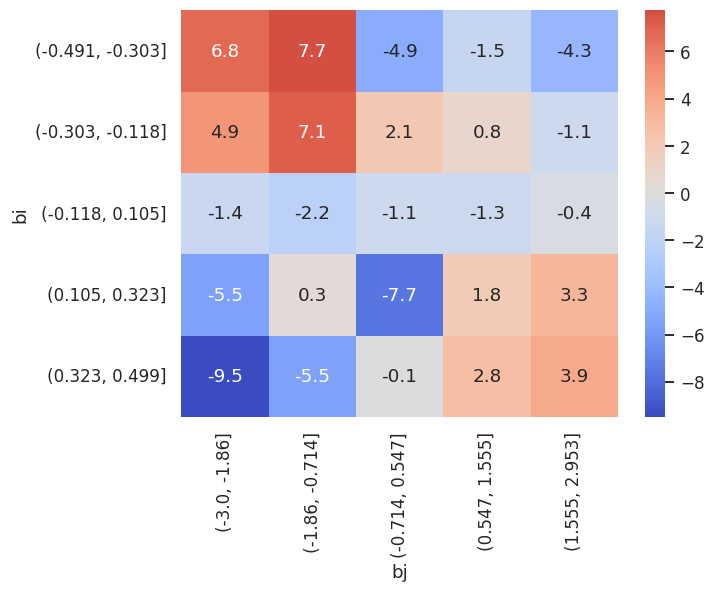

In [19]:
# TODO: agreguen lo que hayan encontrado y midan.
# %%
# 2. Para los 2-3 pares con |corr| más alta: heatmap 2D del residual promedio
# (revela el patrón visualmente en vez de resumirlo en un solo número)
xi, xj = "x4", "x10"  # llenar con el par candidato
bins_i = pd.qcut(X_val[xi], q=5, duplicates="drop")
bins_j = pd.qcut(X_val[xj], q=5, duplicates="drop")
tabla = pd.DataFrame({"res": residuales_v2, "bi": bins_i, "bj": bins_j})
pivot = tabla.pivot_table(values="res", index="bi", columns="bj", aggfunc="mean")
sns.heatmap(pivot, annot=True, fmt=".1f", cmap="coolwarm", center=0)
plt.show()

In [20]:
# %%
import statsmodels.api as sm

xi, xj = "x4", "x10"  # tu par candidato del paso 1

columnas_extra = {
    "x7_sq": lambda d: d["x7"]**2,
    "log_x12": lambda d: np.log(d["x12"]),
    "interaccion": lambda d: d[xi] * d[xj],
}

def construye(df):
    salida = df[VARIABLES].copy()
    for nombre, f in columnas_extra.items():
        salida[nombre] = f(df)
    return salida

X_train_int = sm.add_constant(construye(X_train))
modelo_sm = sm.OLS(y_train, X_train_int).fit()
print(modelo_sm.summary())

                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     90.87
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          1.20e-141
Time:                        14:42:32   Log-Likelihood:                -2107.7
No. Observations:                 600   AIC:                             4247.
Df Residuals:                     584   BIC:                             4318.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const           0.7751      1.083      0.716      

In [21]:
# %%
modelo_v3, mse_v3, residuales_v3, construye_v3 = ajusta({
    "x7_sq": lambda d: d["x7"]**2,
    "log_x12": lambda d: np.log(d["x12"]),
    "x4_x10": lambda d: d["x4"] * d["x10"],
})
print(f"v2 + x4×x10 -> MSE: {mse_v3:.2f}  (v2: 89.44, baseline: 101.98)")

# %%
# Significancia en TRAIN (no en validación, que ya usaste para encontrar el par)
X_train_int = sm.add_constant(construye_v3(X_train))
modelo_sm = sm.OLS(y_train, X_train_int).fit()
print(modelo_sm.summary())

v2 + x4×x10 -> MSE: 69.88  (v2: 89.44, baseline: 101.98)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.700
Model:                            OLS   Adj. R-squared:                  0.692
Method:                 Least Squares   F-statistic:                     90.87
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          1.20e-141
Time:                        14:42:32   Log-Likelihood:                -2107.7
No. Observations:                 600   AIC:                             4247.
Df Residuals:                     584   BIC:                             4318.
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------

---
## Parte 4. El otro camino: fuerza bruta

Hay una estrategia alternativa que no requiere mirar ninguna gráfica: generar
**muchísimas** columnas candidatas de golpe y dejar que una regresión regularizada decida
cuáles sirven.

`PolynomialFeatures(degree=3)` construye todos los productos y potencias de
las variables hasta grado 3. Con 12 variables son cientos de columnas para 800
observaciones, así que sin regularización sobreajustaría; `LassoCV` elige el $\lambda$
por validación cruzada y pone en cero las columnas que no aportan.

Impleméntenlo y **compárenlo contra su modelo de la Parte 3**.

In [22]:
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

# TODO: camino B. Pipeline sugerido:
#   PolynomialFeatures(degree=3) -> StandardScaler -> LassoCV
#
# Estandaricen antes del Lasso: la penalización castiga coeficientes grandes, y sin
# estandarizar "grande" depende de las unidades de cada columna.
#
# Reporten el MSE de validación y cuántas columnas dejó distintas de cero.
# %%
from sklearn.linear_model import LassoCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

poly = PolynomialFeatures(degree=3, include_bias=False)

pipeline = Pipeline([
    ("poly", poly),
    ("scaler", StandardScaler()),
    ("lasso", LassoCV(cv=5, random_state=SEMILLA, max_iter=10000)),
])

pipeline.fit(X_train[VARIABLES], y_train)
pred_val = pipeline.predict(X_val[VARIABLES])
mse_lasso = mean_squared_error(y_val, pred_val)

lasso = pipeline.named_steps["lasso"]
nombres = poly.get_feature_names_out(VARIABLES)
coefs = lasso.coef_
n_distintas_de_cero = np.sum(coefs != 0)

print(f"Lasso (poly grado 3) -> MSE: {mse_lasso:.2f}  (v3 a mano: {mse_v3:.2f}, baseline: {mse:.2f})")
print(f"lambda elegido (alpha_): {lasso.alpha_:.4f}")
print(f"Columnas generadas: {len(nombres)}   Distintas de cero: {n_distintas_de_cero}")

# %%
# Qué sobrevivió, ordenado por magnitud del coeficiente estandarizado
sobrevivientes = pd.Series(coefs, index=nombres)
sobrevivientes = sobrevivientes[sobrevivientes != 0].sort_values(key=abs, ascending=False)
print(sobrevivientes.to_string())

Lasso (poly grado 3) -> MSE: 59.01  (v3 a mano: 69.88, baseline: 101.98)
lambda elegido (alpha_): 0.5843
Columnas generadas: 454   Distintas de cero: 34
x1^3          7.658148
x4 x10        4.686068
x10           2.800351
x6^2          2.425712
x7^2          2.042130
x6 x7^2       1.979341
x7^2 x12      1.438717
x11^3        -0.692546
x5^2 x6       0.438318
x1 x7^2       0.291038
x4^2 x12      0.277131
x4^2 x10      0.253218
x5^2 x12      0.235746
x6 x10 x11    0.200108
x3^2 x6       0.188817
x7            0.166775
x1 x4 x10    -0.139734
x10 x12       0.139076
x1 x10^2      0.135466
x1 x8 x9     -0.132872
x8 x10       -0.125017
x6 x10        0.114761
x2 x7^2       0.096578
x2 x7         0.080667
x3^2 x12      0.078924
x1 x8        -0.071466
x3 x6 x8     -0.069299
x6 x12        0.062532
x3 x9 x10    -0.045546
x2 x4 x8     -0.045334
x2 x3 x9      0.044476
x4 x9^2       0.031012
x4 x10 x11    0.017051
x2            0.016686


In [23]:
print(f"Modelo a mano (Parte 3): MSE {mse_v3:.2f}, {3} términos extra interpretables")
print(f"Lasso (Parte 4):         MSE {mse_lasso:.2f}, {n_distintas_de_cero} columnas activas de {len(nombres)}")

Modelo a mano (Parte 3): MSE 69.88, 3 términos extra interpretables
Lasso (Parte 4):         MSE 59.01, 34 columnas activas de 454


In [24]:
# %%
modelo_v4, mse_v4, residuales_v4, construye_v4 = ajusta({
    "x7_sq": lambda d: d["x7"]**2,
    "log_x12": lambda d: np.log(d["x12"]),
    "x4_x10": lambda d: d["x4"] * d["x10"],
    "x6_sq": lambda d: d["x6"]**2,
})
print(f"v3 + x6² -> MSE: {mse_v4:.2f}  (v3: {mse_v3:.2f})")

X_train_v4 = sm.add_constant(construye_v4(X_train))
print(sm.OLS(y_train, X_train_v4).fit().summary())

v3 + x6² -> MSE: 69.10  (v3: 69.88)
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.706
Model:                            OLS   Adj. R-squared:                  0.697
Method:                 Least Squares   F-statistic:                     87.32
Date:                Sun, 13 Sep 2026   Prob (F-statistic):          5.57e-143
Time:                        14:42:39   Log-Likelihood:                -2102.1
No. Observations:                 600   AIC:                             4238.
Df Residuals:                     583   BIC:                             4313.
Df Model:                          16                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          3

### 4.1 La pregunta que vale la respuesta

Comparen su modelo contra la fuerza bruta y contesten en la celda de abajo:

1. ¿Cuál dio menor MSE de validación?
2. Si su modelo guiado por gráficas le ganó a la fuerza bruta: **¿por qué?** Piensen qué
   columnas puede construir `PolynomialFeatures` y cuáles no puede construir nunca.
3. Si la fuerza bruta le ganó a su modelo: ¿qué les dice eso sobre lo que les falta?
4. ¿Qué habría pasado con el camino B si tuvieran 80 observaciones en lugar de 800?


el de fuerza bruta dio menos mse de validacion, le gano a mi modelo. Por 10 unicades cuadradas

PolynomialFeatures(degree=3) solo puede construir un tipo de objeto: monomios xi^a · xj^b · xk^c donde los exponentes son enteros no negativos y a+b+c ≤ 3. Eso es literalmente todo lo que existe en su espacio de columnas posibles.

Pero no puede construir:
- Logaritmos, raíces, o cualquier potencia no entera (log(x), √x, x^0.7)
- Cocientes entre variables (xi/xj)
- Funciones de umbral o indicadoras (1[x > c]) — cualquier cosa que dependa de un parámetro c que hay que estimar aparte
- Funciones periódicas (sin, cos)
- Funciones tipo bisagra (max(x-c, 0))

Cuando la relación real es, por ejemplo, log(x12), un polinomio de grado 3 solo puede aproximarla combinando x12, x12², x12³ con los coeficientes justos para que la curva se parezca a un logaritmo en el rango de tus datos. Esa aproximación gasta 3 grados de libertad para lograr lo que yo logre con 1 término exacto.

Por qué fuerza bruta podría ganarle a gráficas
Si Lasso encuentra algo que yo no, no es porque el método de gráficas sea malo, es porque tu ejecución del método fue necesariamente incompleta. Hay dos huecos estructurales en el paso 2:
yo solo revise pares. PolynomialFeatures(degree=3) también genera triples (xi·xj·xk). Si la estructura real involucra tres variables a la vez, ningún heatmap 2D de un par la iba a mostrar — necesitarías un heatmap en 3D, que nadie grafica a mano.
Yo solo mire residuales contra una variable a la vez (Parte 2) o productos de a dos (Parte 3), priorizados por correlación. Un efecto cuadrático puro en una variable que individualmente no mostró curvatura visible en su scatter contra y, o una interacción que quedó fuera de tu top-10 por correlación pero que sí es real, simplemente no entra en tu campo de visión con el proceso.

La comparación que importa es n (número de datos) contra p (número de columnas candidatas).

Con n=800, tienes casi el doble de datos que columnas — ya es ajustado, pero manejable: LassoCV con 5 folds tiene ~130-140 observaciones por fold para decidir qué tan bien generaliza cada valor de λ.

Con n=80, tendrías menos observaciones que columnas candidatas (80 contra 454) — es el régimen "alta dimensión, pocos datos" donde varias cosas se rompen a la vez:

---
## Parte 5. Bitácora

Esta parte vale tanto como el MSE. Una fila por hipótesis, **incluidas las que
fallaron** — sobre todo las que fallaron.

Si no tienen al menos un callejón sin salida documentado, esta parte vale cero: significa
que no exploraron, o que le pidieron la respuesta a alguien.

| # | Hipótesis | Gráfica que la probó | Término agregado | MSE antes → después | ¿La sugirió la IA o yo? |
|---|---|---|---|---|---|
| 1 | | | | | |
| 2 | | | | | |
| 3 | | | | | |
| 4 | | | | | |
| 5 | | | | | |
| 6 | | | | | |
| 7 | | | | | |
| 8 | | | | | |

### 5.1 Su modelo final, en palabras

Escriban la función que creen que genera los datos. Algo de la forma
`y = a + b*x? + c*f(x?) + ... + ruido`, con los nombres de sus variables.

y = a + b1·x1 + b6·x6 + b10·x10 + c·x7² + d·log(x12) + e·(x4·x10) + ruido

### 5.2 Dónde se equivocó su IA

Cuenten **un** momento concreto en el que la IA les dijo algo que resultó falso o
inútil para sus datos, y cómo lo detectaron. Si dicen que nunca falló, es que no la
interrogaron lo suficiente.

La IA leyo mal el heatmap, creyo que habia correlacion entre x_1 y x_12, pero era con y.

### 5.3 Cuándo pararon y por qué

`/validar` les dice cuál es el MSE meta: el error del modelo bien especificado, que es
**ruido puro** y no se puede bajar. ¿Qué tan cerca quedaron? ¿Cómo supieron que ya no
valía la pena seguir?

*(Su respuesta aquí)*

A 10 unidades. 

---
## Entrega

Corran la celda de abajo: ajusta **su modelo final** usando *todo* `train` (ya no solo la
partición de entrenamiento — con más datos, mejores coeficientes) y escribe el archivo de
predicciones en el lugar exacto donde el bot lo busca.

In [ ]:
# TODO: pongan aquí las columnas derivadas de su modelo final, con el mismo formato
# que usaron en `ajusta`. Si su modelo final es el baseline crudo, déjenlo vacío.
MI_MODELO = {
    # "nombre_del_termino": lambda d: ...,
    
    "x7_sq": lambda d: d["x7"]**2,
    "log_x12": lambda d: np.log(d["x12"]),
    "x4_x10": lambda d: d["x4"] * d["x10"],
}



def construye_final(df):
    salida = df[VARIABLES].copy()
    for nombre, f in MI_MODELO.items():
        salida[nombre] = f(df)
    return salida


# La estimación honesta de su MSE: ajustada SOLO en la partición de entrenamiento
# y medida en validación. Este es el número que deberían creer.
_, mse_estimado, _, _ = ajusta(MI_MODELO)
print(f"MSE estimado (ajustado en train, medido en validación): {mse_estimado:.2f}")

# Y ahora sí, el modelo que entregan: reajustado con TODO train, porque con 800
# observaciones en lugar de 600 los coeficientes salen mejores. Ojo: a este modelo
# ya no se le puede medir el MSE en validación, porque validación fue parte de su
# entrenamiento. Medirlo ahí daría un número optimista y falso.
modelo_final = LinearRegression().fit(construye_final(train), train["y"])
predicciones = modelo_final.predict(construye_final(test))

assert len(predicciones) == 400, f"deben ser 400 predicciones, hay {len(predicciones)}"
assert np.isfinite(predicciones).all(), "hay predicciones NaN o infinitas"

destino = RAIZ / "entregas/tarea-01" / CARPETA
destino.mkdir(parents=True, exist_ok=True)
pd.DataFrame({"y": predicciones}).to_csv(destino / "predicciones.csv", index=False)

print(f"\nEscrito: {destino.relative_to(RAIZ)}/predicciones.csv")
print(f"{len(predicciones)} predicciones, rango {predicciones.min():.2f} a {predicciones.max():.2f}")

MSE estimado (ajustado en train, medido en validación): 101.98

Escrito: entregas/tarea-01/vca1fec98/predicciones.csv
400 predicciones, rango -11.42 a 36.04


### Los últimos pasos

El detalle está en **`tareas/tarea_01_README.md`**, que trae dos caminos: hacer todo en
**GitHub Codespaces** (en el navegador, sin instalar nada) o en **su computadora**. Los
dos son válidos; si nunca han configurado Python, vayan por Codespaces.

En resumen, igual en los dos casos:

1. Hagan commit de este notebook **y** de su `predicciones.csv`.
2. `git push` a su rama en su fork.
3. Abran un Pull Request al repo del curso.
4. Comenten **`/validar`** en el PR. Les confirma el formato y les dice su MSE objetivo,
   sin gastar intento. Úsenlo siempre antes de calificar.
5. Cuando estén listos, comenten **`/calificar`**. Eso sí gasta uno de sus 3 intentos.

Si `/validar` les marca un error, corrijan, hagan push otra vez y vuelvan a comentar
`/validar`. Las veces que quieran.